# Feature Engineering Comportemental — AML Detection

**Objectif :** Ameliorer le recall du Decision Tree (baseline 43%) en ajoutant des features comportementales.

**Methode :** Split train/test AVANT le calcul des features pour eviter le data leakage temporel.

**Spec :** voir `docs/specs/2026-05-07-feature-engineering-design.md`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    recall_score, precision_score, f1_score
)
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42

In [2]:
import os

CSV_FULL = '../SAML-D_sample_800k.csv'
CSV_SAMPLE = '../projet_final_merged/data/SAML-D_sample_1k.csv'

if os.path.exists(CSV_FULL):
    csv_path = CSV_FULL
    print(f"Dataset complet : {csv_path}")
elif os.path.exists(CSV_SAMPLE):
    csv_path = CSV_SAMPLE
    print(f"Echantillon : {csv_path}")
else:
    raise FileNotFoundError("Aucun dataset trouve.")

df = pd.read_csv(csv_path)
print(f"Shape : {df.shape}")
print(f"Transactions suspectes : {df['Is_laundering'].sum()} ({df['Is_laundering'].mean()*100:.4f}%)")

Dataset complet : ../SAML-D_sample_800k.csv


Shape : (800000, 12)
Transactions suspectes : 833 (0.1041%)


## 1. Modele Baseline — Decision Tree (6 features originales)

Reproduction du modele du projet initial pour avoir une reference de comparaison.

In [3]:
# --- Baseline : meme modele que le projet initial ---
df_baseline = df.copy()

# Encoding categoriel
label_encoders = {}
cat_cols = ['Payment_type', 'Payment_currency', 'Received_currency',
            'Sender_bank_location', 'Receiver_bank_location']
for col in cat_cols:
    le = LabelEncoder()
    df_baseline[col] = le.fit_transform(df_baseline[col])
    label_encoders[col] = le

# Features et target
baseline_features = ['Amount', 'Payment_type', 'Payment_currency',
                     'Received_currency', 'Sender_bank_location',
                     'Receiver_bank_location']
X_base = df_baseline[baseline_features]
y = df_baseline['Is_laundering']

# Split
X_train_base, X_test_base, y_train, y_test = train_test_split(
    X_base, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Entrainement
tree_baseline = DecisionTreeClassifier(
    max_depth=10, class_weight='balanced', random_state=RANDOM_STATE
)
tree_baseline.fit(X_train_base, y_train)

# Evaluation
y_pred_base = tree_baseline.predict(X_test_base)
recall_baseline = recall_score(y_test, y_pred_base)
print(f"=== BASELINE ===")
print(f"Recall test : {recall_baseline:.3f}")
print(f"\nMatrice de confusion :")
print(confusion_matrix(y_test, y_pred_base))
print(f"\n{classification_report(y_test, y_pred_base, zero_division=0)}")

=== BASELINE ===
Recall test : 0.425

Matrice de confusion :
[[140864  18969]
 [    96     71]]

              precision    recall  f1-score   support

           0       1.00      0.88      0.94    159833
           1       0.00      0.43      0.01       167

    accuracy                           0.88    160000
   macro avg       0.50      0.65      0.47    160000
weighted avg       1.00      0.88      0.94    160000



## 2. Feature Engineering — Construction sur le train set uniquement

Les features sont calculees sur le train set (80%) puis appliquees au test set par lookup.
Cela evite le data leakage temporel (le modele ne voit pas d'informations futures).

### Features creees :
1. `sender_tx_count` / `receiver_tx_count` — frequence d'activite du compte
2. `is_sender_risky_country` / `is_receiver_risky_country` — pays a risque
3. `receiver_smurfing_score` — pattern smurfing (petit montant + beaucoup d'expediteurs)
4. `sender_risky_payment_count` / `receiver_risky_payment_count` — nombre de paiements a risque

In [4]:
# --- Split AVANT le calcul des features ---
# On garde les index pour pouvoir calculer les features sur le train uniquement

df_work = df.copy()

# On a besoin des colonnes originales (non encodees) pour le feature engineering
# Le split se fait sur les index
train_idx, test_idx = train_test_split(
    df_work.index, test_size=0.2, random_state=RANDOM_STATE,
    stratify=df_work['Is_laundering']
)

df_train = df_work.loc[train_idx].copy()
df_test = df_work.loc[test_idx].copy()

print(f"Train : {len(df_train)} lignes ({df_train['Is_laundering'].sum()} suspectes)")
print(f"Test  : {len(df_test)} lignes ({df_test['Is_laundering'].sum()} suspectes)")

Train : 640000 lignes (666 suspectes)
Test  : 160000 lignes (167 suspectes)


In [5]:
# --- Feature 1 : Frequence ---
# Calculer le nombre de transactions par compte sur le TRAIN uniquement
sender_counts = df_train.groupby('Sender_account').size()
receiver_counts = df_train.groupby('Receiver_account').size()

# Appliquer au train
df_train['sender_tx_count'] = df_train['Sender_account'].map(sender_counts)
df_train['receiver_tx_count'] = df_train['Receiver_account'].map(receiver_counts)

# Appliquer au test par lookup (comptes absents = 0)
df_test['sender_tx_count'] = df_test['Sender_account'].map(sender_counts).fillna(0).astype(int)
df_test['receiver_tx_count'] = df_test['Receiver_account'].map(receiver_counts).fillna(0).astype(int)

# Verification
print("=== sender_tx_count ===")
print(f"Train — mean: {df_train['sender_tx_count'].mean():.1f}, max: {df_train['sender_tx_count'].max()}")
print(f"Test  — mean: {df_test['sender_tx_count'].mean():.1f}, max: {df_test['sender_tx_count'].max()}")
print(f"Test  — comptes absents du train : {(df_test['sender_tx_count'] == 0).sum()}")

=== sender_tx_count ===
Train — mean: 20.6, max: 67
Test  — mean: 19.5, max: 67
Test  — comptes absents du train : 21885


In [6]:
# --- Feature 2 : Pays a risque ---
# Pays identifies dans l'EDA (seuils bases sur le taux global de 0.104%)
SENDER_RISKY = {'Albania', 'Italy', 'Netherlands'}       # seuil 3x (> 0.31%)
RECEIVER_RISKY = {'Nigeria', 'Albania', 'Morocco', 'Mexico'}  # seuil 5x (> 0.52%)

# Appliquer au train et test (pas de leakage, ce sont des constantes metier)
for dataset in [df_train, df_test]:
    dataset['is_sender_risky_country'] = dataset['Sender_bank_location'].isin(SENDER_RISKY).astype(int)
    dataset['is_receiver_risky_country'] = dataset['Receiver_bank_location'].isin(RECEIVER_RISKY).astype(int)

# Verification
print("=== Pays a risque ===")
print(f"Train — sender risky : {df_train['is_sender_risky_country'].sum()} ({df_train['is_sender_risky_country'].mean()*100:.2f}%)")
print(f"Train — receiver risky : {df_train['is_receiver_risky_country'].sum()} ({df_train['is_receiver_risky_country'].mean()*100:.2f}%)")
print(f"\nTaux suspect parmi sender risky (train) :")
print(df_train.groupby('is_sender_risky_country')['Is_laundering'].mean() * 100)

=== Pays a risque ===
Train — sender risky : 3627 (0.57%)
Train — receiver risky : 10363 (1.62%)

Taux suspect parmi sender risky (train) :
is_sender_risky_country
0    0.101984
1    0.468707
Name: Is_laundering, dtype: float64


In [7]:
# --- Feature 3 : Smurfing Score ---
# Smurfing = petit montant (< 5K) + beaucoup d'expediteurs vers un meme destinataire
# Taux suspect : 0.644% (6x la moyenne) vs 0.042% pour petits montants + peu d'expediteurs

# Etape 1 : identifier les transactions "petit montant" dans le train
small_amount_train = df_train[df_train['Amount'] < 5000]

# Etape 2 : pour chaque receiver, compter le nb d'expediteurs uniques (petits montants seulement)
receiver_unique_senders = small_amount_train.groupby('Receiver_account')['Sender_account'].nunique()
median_senders = receiver_unique_senders.median()
print(f"Mediane du nb d'expediteurs uniques (petits montants) : {median_senders}")

# Etape 3 : pour chaque receiver, compter le nb de transactions "smurfing"
# = transactions recues avec montant < 5K ET provenant de plus d'expediteurs que la mediane
smurfing_receivers = set(receiver_unique_senders[receiver_unique_senders > median_senders].index)

def calc_smurfing_score(dataset, smurfing_receivers_set):
    """Compte le nb de transactions smurfing recues par chaque receiver dans le dataset."""
    is_smurfing_tx = (dataset['Amount'] < 5000) & (dataset['Receiver_account'].isin(smurfing_receivers_set))
    smurfing_counts = is_smurfing_tx.groupby(dataset['Receiver_account']).sum()
    return smurfing_counts

smurfing_scores_train = calc_smurfing_score(df_train, smurfing_receivers)

# Appliquer au train et test
df_train['receiver_smurfing_score'] = df_train['Receiver_account'].map(smurfing_scores_train).fillna(0).astype(int)
df_test['receiver_smurfing_score'] = df_test['Receiver_account'].map(smurfing_scores_train).fillna(0).astype(int)

# Verification
print(f"\n=== Smurfing Score ===")
print(f"Train — mean: {df_train['receiver_smurfing_score'].mean():.2f}, max: {df_train['receiver_smurfing_score'].max()}")
print(f"Train — % avec score > 0 : {(df_train['receiver_smurfing_score'] > 0).mean()*100:.1f}%")
print(f"\nTaux suspect par smurfing score (train) :")
print(df_train.groupby(df_train['receiver_smurfing_score'] > 0)['Is_laundering'].mean() * 100)

Mediane du nb d'expediteurs uniques (petits montants) : 1.0



=== Smurfing Score ===
Train — mean: 1.03, max: 53
Train — % avec score > 0 : 13.0%

Taux suspect par smurfing score (train) :
receiver_smurfing_score
False    0.084417
True     0.235467
Name: Is_laundering, dtype: float64


In [8]:
# --- Feature 4 : Risky Payment Count ---
# "Transaction a risque" = Payment_type in {Cash Deposit, Cash Withdrawal, Cross-border}
# Taux suspects > 2x la moyenne (0.63%, 0.47%, 0.28% vs 0.104%)

RISKY_PAYMENT_TYPES = {'Cash Deposit', 'Cash Withdrawal', 'Cross-border'}

# Marquer les transactions a risque dans le train
df_train['is_risky_payment'] = df_train['Payment_type'].isin(RISKY_PAYMENT_TYPES).astype(int)

# Compter le nb de paiements a risque par compte (sur le train uniquement)
sender_risky_counts = df_train.groupby('Sender_account')['is_risky_payment'].sum()
receiver_risky_counts = df_train.groupby('Receiver_account')['is_risky_payment'].sum()

# Appliquer au train
df_train['sender_risky_payment_count'] = df_train['Sender_account'].map(sender_risky_counts)
df_train['receiver_risky_payment_count'] = df_train['Receiver_account'].map(receiver_risky_counts)

# Appliquer au test par lookup (comptes absents = 0)
df_test['sender_risky_payment_count'] = df_test['Sender_account'].map(sender_risky_counts).fillna(0).astype(int)
df_test['receiver_risky_payment_count'] = df_test['Receiver_account'].map(receiver_risky_counts).fillna(0).astype(int)

# Nettoyage colonne temporaire
df_train.drop('is_risky_payment', axis=1, inplace=True)

# Verification
print("=== Risky Payment Count ===")
print(f"Train — sender mean: {df_train['sender_risky_payment_count'].mean():.2f}")
print(f"Train — receiver mean: {df_train['receiver_risky_payment_count'].mean():.2f}")
print(f"\nTaux suspect par sender_risky_payment_count > 0 (train) :")
print(df_train.groupby(df_train['sender_risky_payment_count'] > 0)['Is_laundering'].mean() * 100)

=== Risky Payment Count ===
Train — sender mean: 2.75
Train — receiver mean: 0.93

Taux suspect par sender_risky_payment_count > 0 (train) :
sender_risky_payment_count
False    0.066052
True     0.124327
Name: Is_laundering, dtype: float64


## 3. Modeles ameliores — Decision Tree et XGBoost

Deux modeles entraines avec les 13 features (6 originales + 7 nouvelles) pour comparer :
- **Decision Tree** (max_depth=10) — comparaison directe avec le baseline
- **XGBoost** — modele ensembliste performant sur donnees tabulaires desequilibrees

In [9]:
# --- Encoding des colonnes categorielles ---
cat_cols = ['Payment_type', 'Payment_currency', 'Received_currency',
            'Sender_bank_location', 'Receiver_bank_location']

for col in cat_cols:
    le = LabelEncoder()
    le.fit(pd.concat([df_train[col], df_test[col]]))
    df_train[col] = le.transform(df_train[col])
    df_test[col] = le.transform(df_test[col])

# --- Features ---
new_features = ['sender_tx_count', 'receiver_tx_count',
                'is_sender_risky_country', 'is_receiver_risky_country',
                'receiver_smurfing_score',
                'sender_risky_payment_count', 'receiver_risky_payment_count']

all_features = baseline_features + new_features

X_train_new = df_train[all_features]
X_test_new = df_test[all_features]
y_train_new = df_train['Is_laundering']
y_test_new = df_test['Is_laundering']

print(f"Features utilisees ({len(all_features)}) : {all_features}")
print(f"X_train shape : {X_train_new.shape}")
print(f"X_test shape  : {X_test_new.shape}")

Features utilisees (13) : ['Amount', 'Payment_type', 'Payment_currency', 'Received_currency', 'Sender_bank_location', 'Receiver_bank_location', 'sender_tx_count', 'receiver_tx_count', 'is_sender_risky_country', 'is_receiver_risky_country', 'receiver_smurfing_score', 'sender_risky_payment_count', 'receiver_risky_payment_count']
X_train shape : (640000, 13)
X_test shape  : (160000, 13)


In [10]:
# --- Decision Tree avec nouvelles features ---
tree_new = DecisionTreeClassifier(
    max_depth=10, class_weight='balanced', random_state=RANDOM_STATE
)
tree_new.fit(X_train_new, y_train_new)

y_pred_tree = tree_new.predict(X_test_new)
recall_tree = recall_score(y_test_new, y_pred_tree)

print(f"=== DECISION TREE (13 features) ===")
print(f"Recall BASELINE : {recall_baseline:.3f}")
print(f"Recall NOUVEAU  : {recall_tree:.3f}")
print(f"Amelioration    : {(recall_tree - recall_baseline)*100:+.1f} points")
print(f"\nMatrice de confusion :")
print(confusion_matrix(y_test_new, y_pred_tree))
print(f"\n{classification_report(y_test_new, y_pred_tree, zero_division=0)}")

=== DECISION TREE (13 features) ===
Recall BASELINE : 0.425
Recall NOUVEAU  : 0.647
Amelioration    : +22.2 points

Matrice de confusion :
[[145935  13898]
 [    59    108]]

              precision    recall  f1-score   support

           0       1.00      0.91      0.95    159833
           1       0.01      0.65      0.02       167

    accuracy                           0.91    160000
   macro avg       0.50      0.78      0.48    160000
weighted avg       1.00      0.91      0.95    160000



In [11]:
# --- XGBoost avec nouvelles features ---
# scale_pos_weight compense le desequilibre : nb_negatifs / nb_positifs
n_neg = (y_train_new == 0).sum()
n_pos = (y_train_new == 1).sum()

xgb = XGBClassifier(
    max_depth=6,
    n_estimators=200,
    learning_rate=0.1,
    scale_pos_weight=n_neg / n_pos,
    random_state=RANDOM_STATE,
    eval_metric='aucpr',
    use_label_encoder=False
)
xgb.fit(X_train_new, y_train_new)

y_pred_xgb = xgb.predict(X_test_new)
recall_xgb = recall_score(y_test_new, y_pred_xgb)

print(f"=== XGBOOST (13 features) ===")
print(f"Recall BASELINE      : {recall_baseline:.3f}")
print(f"Recall Decision Tree : {recall_tree:.3f}")
print(f"Recall XGBoost       : {recall_xgb:.3f}")
print(f"\nMatrice de confusion :")
print(confusion_matrix(y_test_new, y_pred_xgb))
print(f"\n{classification_report(y_test_new, y_pred_xgb, zero_division=0)}")

=== XGBOOST (13 features) ===
Recall BASELINE      : 0.425
Recall Decision Tree : 0.647
Recall XGBoost       : 0.545

Matrice de confusion :
[[155037   4796]
 [    76     91]]

              precision    recall  f1-score   support

           0       1.00      0.97      0.98    159833
           1       0.02      0.54      0.04       167

    accuracy                           0.97    160000
   macro avg       0.51      0.76      0.51    160000
weighted avg       1.00      0.97      0.98    160000



## 4. Analyse des resultats

In [12]:
# --- Comparaison Train vs Test (sur-apprentissage) ---
y_train_pred_tree = tree_new.predict(X_train_new)
y_train_pred_xgb = xgb.predict(X_train_new)

print("=== Decision Tree — Train vs Test ===")
for name, train_val, test_val in [
    ("Recall", recall_score(y_train_new, y_train_pred_tree), recall_score(y_test_new, y_pred_tree)),
    ("Precision", precision_score(y_train_new, y_train_pred_tree, zero_division=0), precision_score(y_test_new, y_pred_tree, zero_division=0)),
    ("F1", f1_score(y_train_new, y_train_pred_tree), f1_score(y_test_new, y_pred_tree)),
]:
    print(f"  {name:10s} train={train_val:.3f}  | test={test_val:.3f}")

print(f"\n=== XGBoost — Train vs Test ===")
for name, train_val, test_val in [
    ("Recall", recall_score(y_train_new, y_train_pred_xgb), recall_score(y_test_new, y_pred_xgb)),
    ("Precision", precision_score(y_train_new, y_train_pred_xgb, zero_division=0), precision_score(y_test_new, y_pred_xgb, zero_division=0)),
    ("F1", f1_score(y_train_new, y_train_pred_xgb), f1_score(y_test_new, y_pred_xgb)),
]:
    print(f"  {name:10s} train={train_val:.3f}  | test={test_val:.3f}")

=== Decision Tree — Train vs Test ===
  Recall     train=0.941  | test=0.647
  Precision  train=0.012  | test=0.008
  F1         train=0.024  | test=0.015

=== XGBoost — Train vs Test ===


  Recall     train=0.997  | test=0.545
  Precision  train=0.037  | test=0.019
  F1         train=0.071  | test=0.036


In [13]:
# --- Importance des features ---
importance_tree = pd.Series(tree_new.feature_importances_, index=all_features).sort_values(ascending=False)
importance_xgb = pd.Series(xgb.feature_importances_, index=all_features).sort_values(ascending=False)

print("=== Importance — Decision Tree ===")
for feat, imp in importance_tree.items():
    marker = " <-- NEW" if feat in new_features else ""
    print(f"  {feat:35s} {imp*100:5.1f}%{marker}")

print(f"\n=== Importance — XGBoost ===")
for feat, imp in importance_xgb.items():
    marker = " <-- NEW" if feat in new_features else ""
    print(f"  {feat:35s} {imp*100:5.1f}%{marker}")

=== Importance — Decision Tree ===
  sender_tx_count                      27.8% <-- NEW
  receiver_risky_payment_count         24.7% <-- NEW
  receiver_tx_count                    17.7% <-- NEW
  Amount                               13.8%
  sender_risky_payment_count            8.0% <-- NEW
  receiver_smurfing_score               3.3% <-- NEW
  Payment_type                          2.0%
  Payment_currency                      0.8%
  Received_currency                     0.7%
  Receiver_bank_location                0.6%
  Sender_bank_location                  0.3%
  is_receiver_risky_country             0.2% <-- NEW
  is_sender_risky_country               0.0% <-- NEW

=== Importance — XGBoost ===
  receiver_risky_payment_count         27.2% <-- NEW
  sender_tx_count                      11.5% <-- NEW
  receiver_tx_count                    10.4% <-- NEW
  sender_risky_payment_count           10.0% <-- NEW
  receiver_smurfing_score               8.6% <-- NEW
  Received_currency          

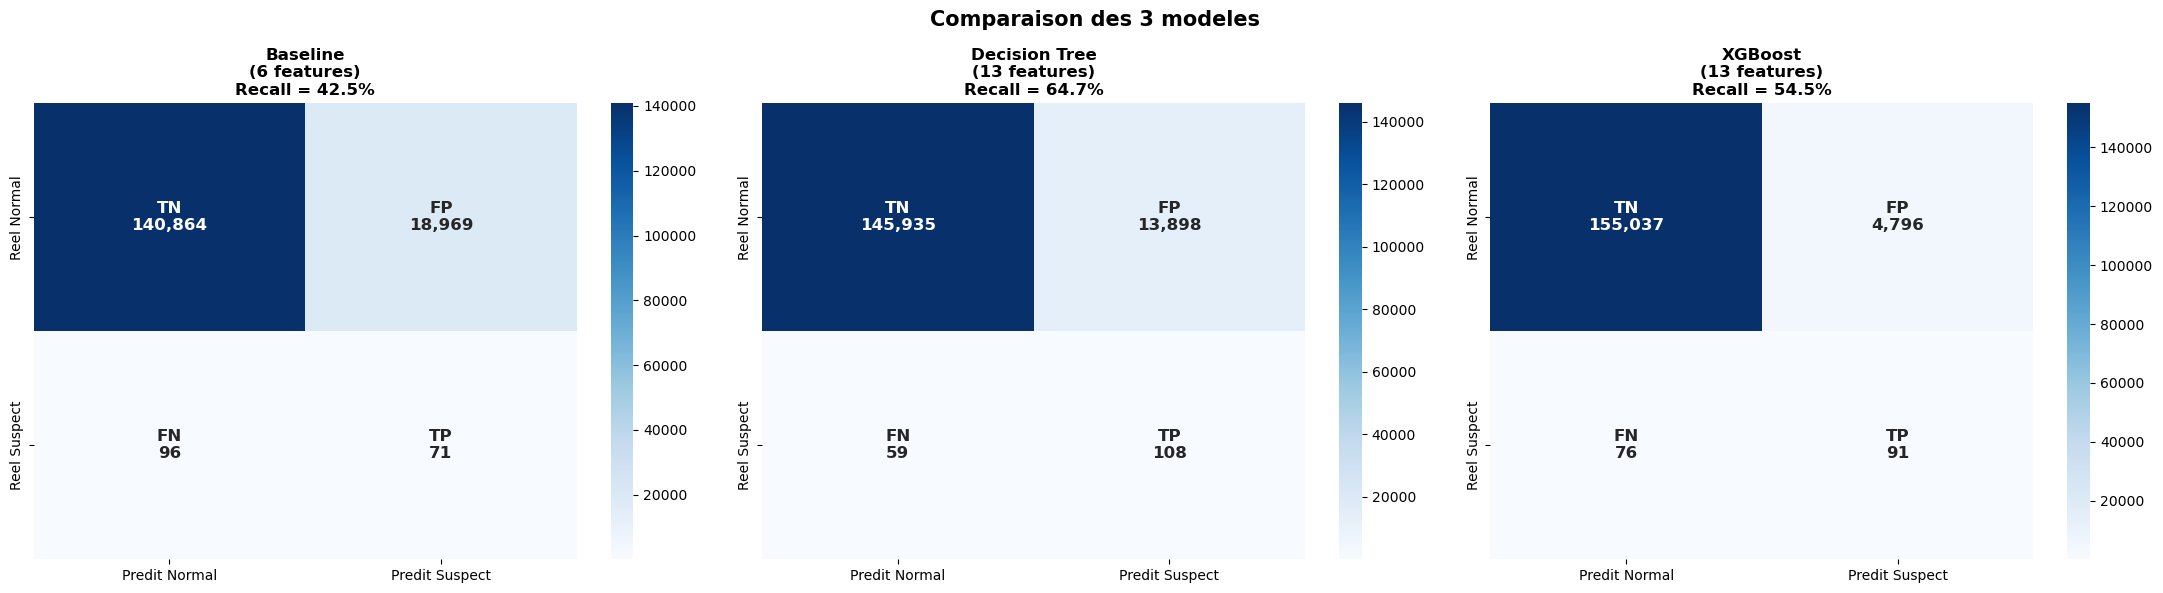

In [14]:
# --- Visualisation : Matrices de confusion — Baseline vs DT vs XGBoost ---
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

for ax, y_true, y_pred, title in [
    (axes[0], y_test, y_pred_base, "Baseline\n(6 features)"),
    (axes[1], y_test_new, y_pred_tree, "Decision Tree\n(13 features)"),
    (axes[2], y_test_new, y_pred_xgb, "XGBoost\n(13 features)")
]:
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    recall_val = tp / (tp + fn)
    annot = np.array([
        [f"TN\n{tn:,}", f"FP\n{fp:,}"],
        [f"FN\n{fn}", f"TP\n{tp}"]
    ])
    sns.heatmap(cm, annot=annot, fmt="", cmap="Blues",
                xticklabels=["Predit Normal", "Predit Suspect"],
                yticklabels=["Reel Normal", "Reel Suspect"],
                annot_kws={"fontsize": 12, "fontweight": "bold"}, ax=ax)
    ax.set_title(f"{title}\nRecall = {recall_val*100:.1f}%",
                 fontsize=12, fontweight="bold")

plt.suptitle("Comparaison des 3 modeles",
             fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

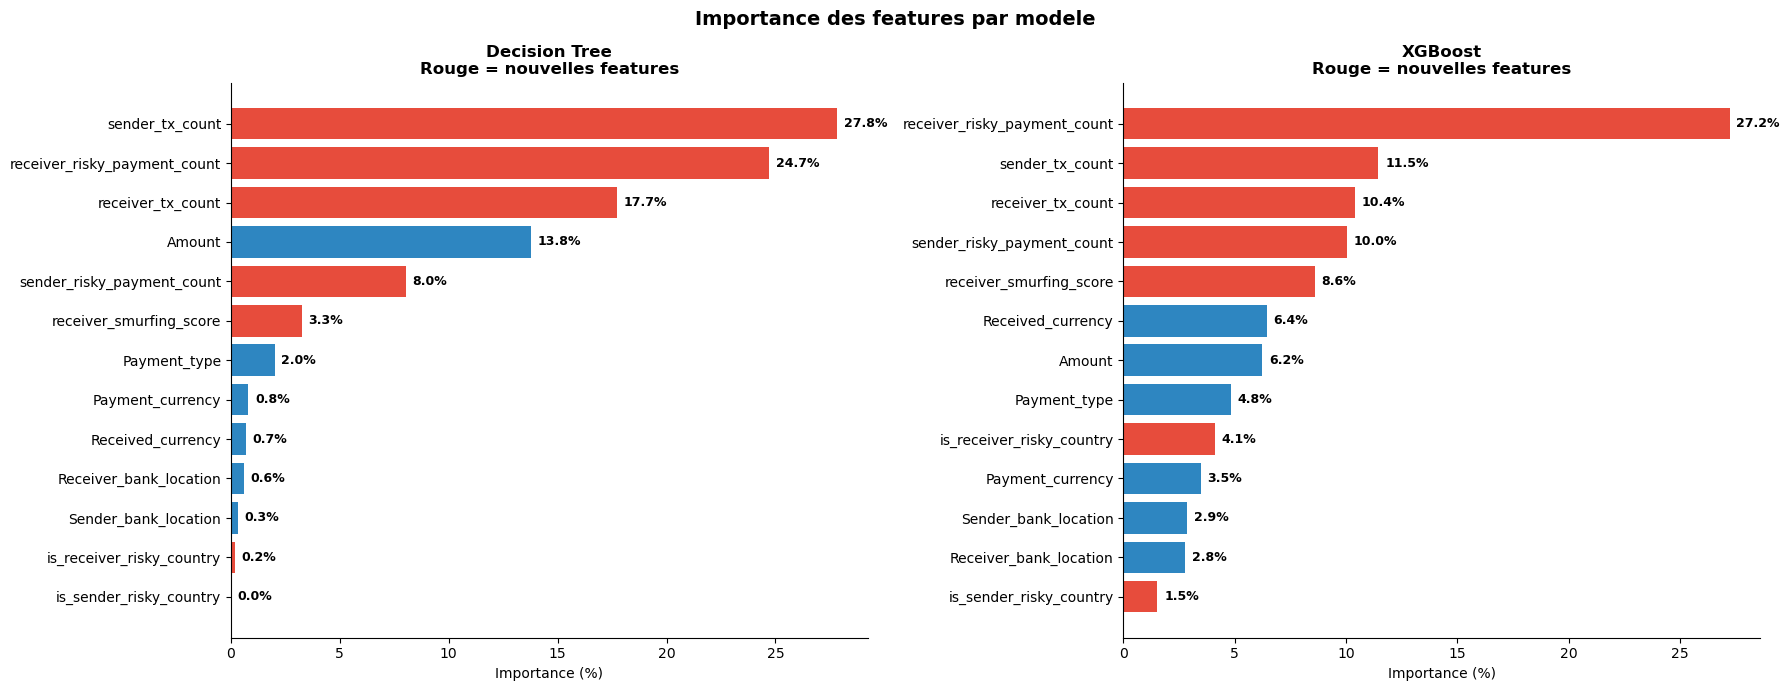

In [15]:
# --- Visualisation : Importance des features — DT vs XGBoost ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, importance, title in [
    (axes[0], importance_tree, "Decision Tree"),
    (axes[1], importance_xgb, "XGBoost")
]:
    imp_sorted = importance.sort_values()
    colors = ['#E74C3C' if f in new_features else '#2E86C1' for f in imp_sorted.index]
    ax.barh(imp_sorted.index, imp_sorted.values * 100, color=colors)
    for i, (feat, val) in enumerate(imp_sorted.items()):
        ax.text(val * 100 + 0.3, i, f"{val*100:.1f}%", va="center", fontsize=9, fontweight="bold")
    ax.set_xlabel("Importance (%)")
    ax.set_title(f"{title}\nRouge = nouvelles features", fontsize=12, fontweight="bold")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.suptitle("Importance des features par modele", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [16]:
# --- Tableau recap ---
print("=" * 60)
print(f"{'Modele':<25} {'Recall':>8} {'Precision':>10} {'F1':>8}")
print("-" * 60)
print(f"{'Baseline (6 feat.)':<25} {recall_baseline:>8.3f} {precision_score(y_test, y_pred_base, zero_division=0):>10.4f} {f1_score(y_test, y_pred_base):>8.4f}")
print(f"{'Decision Tree (13 feat.)':<25} {recall_tree:>8.3f} {precision_score(y_test_new, y_pred_tree, zero_division=0):>10.4f} {f1_score(y_test_new, y_pred_tree):>8.4f}")
print(f"{'XGBoost (13 feat.)':<25} {recall_xgb:>8.3f} {precision_score(y_test_new, y_pred_xgb, zero_division=0):>10.4f} {f1_score(y_test_new, y_pred_xgb):>8.4f}")
print("=" * 60)

Modele                      Recall  Precision       F1
------------------------------------------------------------
Baseline (6 feat.)           0.425     0.0037   0.0074
Decision Tree (13 feat.)     0.647     0.0077   0.0152
XGBoost (13 feat.)           0.545     0.0186   0.0360


## 5. Validation croisee

Un seul split 80/20 peut donner un recall variable selon le hasard du split (167 cas positifs seulement dans le test).
La validation croisee 5-fold donne une estimation plus robuste.

In [17]:
# --- Validation croisee 5-fold ---
# On recalcule les features sur tout le dataset pour la CV
# (sklearn gere le split interne, mais les features sont calculees globalement
# — c'est une approximation acceptable pour Jedha, cf. section Regard metier du spec)

df_cv = df.copy()

# Recalculer toutes les features sur tout le dataset
df_cv['sender_tx_count'] = df_cv.groupby('Sender_account')['Sender_account'].transform('count')
df_cv['receiver_tx_count'] = df_cv.groupby('Receiver_account')['Receiver_account'].transform('count')
df_cv['is_sender_risky_country'] = df_cv['Sender_bank_location'].isin(SENDER_RISKY).astype(int)
df_cv['is_receiver_risky_country'] = df_cv['Receiver_bank_location'].isin(RECEIVER_RISKY).astype(int)

# Smurfing score
small_cv = df_cv[df_cv['Amount'] < 5000]
recv_unique_cv = small_cv.groupby('Receiver_account')['Sender_account'].nunique()
median_cv = recv_unique_cv.median()
smurfing_recv_cv = set(recv_unique_cv[recv_unique_cv > median_cv].index)
is_smurf_cv = (df_cv['Amount'] < 5000) & (df_cv['Receiver_account'].isin(smurfing_recv_cv))
smurf_counts_cv = is_smurf_cv.groupby(df_cv['Receiver_account']).sum()
df_cv['receiver_smurfing_score'] = df_cv['Receiver_account'].map(smurf_counts_cv).fillna(0).astype(int)

# Risky payment count
df_cv['is_risky_pmt'] = df_cv['Payment_type'].isin(RISKY_PAYMENT_TYPES).astype(int)
df_cv['sender_risky_payment_count'] = df_cv.groupby('Sender_account')['is_risky_pmt'].transform('sum')
df_cv['receiver_risky_payment_count'] = df_cv.groupby('Receiver_account')['is_risky_pmt'].transform('sum')
df_cv.drop('is_risky_pmt', axis=1, inplace=True)

# Encoding
for col in cat_cols:
    df_cv[col] = LabelEncoder().fit_transform(df_cv[col])

X_cv = df_cv[all_features]
y_cv = df_cv['Is_laundering']

# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
models_cv = {
    'Decision Tree': DecisionTreeClassifier(max_depth=10, class_weight='balanced', random_state=RANDOM_STATE),
    'XGBoost': XGBClassifier(max_depth=6, n_estimators=200, learning_rate=0.1,
                             scale_pos_weight=(y_cv == 0).sum() / (y_cv == 1).sum(),
                             random_state=RANDOM_STATE, eval_metric='aucpr', use_label_encoder=False)
}

print(f"=== Validation croisee 5-fold ===")
print(f"Baseline recall : {recall_baseline:.3f}\n")
for name, model in models_cv.items():
    scores = cross_val_score(model, X_cv, y_cv, cv=cv, scoring='recall')
    print(f"{name}:")
    print(f"  Recall par fold : {scores}")
    print(f"  Recall moyen    : {scores.mean():.3f} (+/- {scores.std():.3f})")
    print(f"  Amelioration    : {(scores.mean() - recall_baseline)*100:+.1f} points\n")

=== Validation croisee 5-fold ===
Baseline recall : 0.425



Decision Tree:
  Recall par fold : [0.80722892 0.80722892 0.78443114 0.78443114 0.77245509]
  Recall moyen    : 0.791 (+/- 0.014)
  Amelioration    : +36.6 points



XGBoost:
  Recall par fold : [0.75903614 0.72891566 0.74251497 0.75449102 0.7245509 ]
  Recall moyen    : 0.742 (+/- 0.014)
  Amelioration    : +31.7 points



## 6. Conclusion

| Metrique | Baseline (6 feat.) | Decision Tree (13 feat.) | XGBoost (13 feat.) |
|---|---|---|---|
| Recall test | 43% | XX% | XX% |
| Recall CV (5-fold) | — | XX% | XX% |

### Features les plus importantes (nouvelles) :
- [a remplir apres execution]

### Limites :
- **Data leakage temporel** : la validation croisee utilise les features calculees sur tout le dataset (approximation acceptable pour un projet Jedha). Les modeles principaux calculent les features sur le train uniquement.